In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
import glob
import random

import numpy as np
import pandas as pd
from PIL import Image
from itertools import cycle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
from keras.utils import to_categorical
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
tf.config.optimizer.set_experimental_options({'layout_optimizer': False})

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths

zip_path = '/content/drive/MyDrive/dog-breed-identification.zip'
extract_path = '/content/dog_breed_dataset'

# Unzip the dataset
import zipfile
import os

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted!")

# Check dataset structure and load labels

labels_csv_path = os.path.join(extract_path, 'labels.csv')
train_image_path = os.path.join(extract_path, 'train')

if os.path.exists(labels_csv_path):
    labels_df = pd.read_csv(labels_csv_path)
    breeds = labels_df['breed'].unique().tolist()
    print("Total breeds found:", len(breeds))
    print("Example breed folders (from labels.csv):", breeds[:5])

    if os.path.exists(train_image_path):
        print(f"Number of training images found: {len(os.listdir(train_image_path))}")
    else:
        print(f"Training image directory not found at {train_image_path}")
else:
    print(f"labels.csv not found at {labels_csv_path}")
    breeds = []



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted!
Total breeds found: 120
Example breed folders (from labels.csv): ['boston_bull', 'dingo', 'pekinese', 'bluetick', 'golden_retriever']
Number of training images found: 10222


In [ ]:
# Display breeds before and after sorting
print("Before sorting:")
print(breeds)

# Sort the list of breeds (to ensure consistent label order)
breeds.sort()

print("\nAfter sorting:")
print(breeds)

# show how many breeds and a sample of them
print(f"\nTotal breeds: {len(breeds)}")
print("Sample breeds:", breeds[:5])

Before sorting:
['boston_bull', 'dingo', 'pekinese', 'bluetick', 'golden_retriever', 'bedlington_terrier', 'borzoi', 'basenji', 'scottish_deerhound', 'shetland_sheepdog', 'walker_hound', 'maltese_dog', 'norfolk_terrier', 'african_hunting_dog', 'wire-haired_fox_terrier', 'redbone', 'lakeland_terrier', 'boxer', 'doberman', 'otterhound', 'standard_schnauzer', 'irish_water_spaniel', 'black-and-tan_coonhound', 'cairn', 'affenpinscher', 'labrador_retriever', 'ibizan_hound', 'english_setter', 'weimaraner', 'giant_schnauzer', 'groenendael', 'dhole', 'toy_poodle', 'border_terrier', 'tibetan_terrier', 'norwegian_elkhound', 'shih-tzu', 'irish_terrier', 'kuvasz', 'german_shepherd', 'greater_swiss_mountain_dog', 'basset', 'australian_terrier', 'schipperke', 'rhodesian_ridgeback', 'irish_setter', 'appenzeller', 'bloodhound', 'samoyed', 'miniature_schnauzer', 'brittany_spaniel', 'kelpie', 'papillon', 'border_collie', 'entlebucher', 'collie', 'malamute', 'welsh_springer_spaniel', 'chihuahua', 'saluki'

In [ ]:
# Count how many images exist per breed
breed_counts = labels_df['breed'].value_counts()

# See the top breeds and distribution
print(breed_counts.head(20))
print(f"\nMinimum images per breed: {breed_counts.min()}")
print(f"Maximum images per breed: {breed_counts.max()}")


breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
shih-tzu                112
great_pyrenees          111
pomeranian              111
basenji                 110
samoyed                 109
tibetan_terrier         107
airedale                107
leonberg                106
cairn                   106
japanese_spaniel        105
beagle                  105
australian_terrier      102
miniature_pinscher      102
blenheim_spaniel        102
irish_wolfhound         101
Name: count, dtype: int64

Minimum images per breed: 66
Maximum images per breed: 126


In [ ]:

#  Mount Google Drive & Extract Dataset(again use as this was applied next time )

from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, pandas as pd

zip_path = '/content/drive/MyDrive/dog-breed-identification.zip'
extract_path = '/content/dog_breed_dataset'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted!")

# Check dataset structure
!ls -l /content/dog_breed_dataset


# Load labels.csv and inspect

labels_csv_path = os.path.join(extract_path, 'labels.csv')
train_image_path = os.path.join(extract_path, 'train')

if os.path.exists(labels_csv_path):
    df = pd.read_csv(labels_csv_path)
    print("labels.csv loaded — shape:", df.shape)
    print(df.head())
    breeds = df['breed'].unique().tolist()
    print("Total unique breeds:", len(breeds))
else:
    raise FileNotFoundError(f"labels.csv not found at {labels_csv_path}")

if os.path.exists(train_image_path):
    print(f"Training images found: {len(os.listdir(train_image_path))}")
else:
    raise FileNotFoundError(f" Training image directory not found at {train_image_path}")

# PARAMETERS

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import EfficientNetB3, preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np, math

IMG_SIZE = (300, 300)
BATCH_SIZE = 16
SEED = 42
NUM_BREEDS = 120
TRAIN_DIR = train_image_path

# Select all 120 breeds

top_breeds = df['breed'].value_counts().nlargest(NUM_BREEDS).index.tolist()
print("\nSelected breeds:", len(top_breeds))

df_top = df[df['breed'].isin(top_breeds)].copy()
df_top['filename'] = df_top['id'] + '.jpg'
df_top['filepath'] = df_top['filename'].apply(lambda x: os.path.join(TRAIN_DIR, x))
df_top = df_top[df_top['filepath'].apply(os.path.exists)]  # keep only existing files
df_top.reset_index(drop=True, inplace=True)

print("Images available after filtering:", len(df_top))


# Stratified Train/Val/Test Split
#72%training,18% validation,10% test

trainval_df, test_df = train_test_split(df_top, test_size=0.10, stratify=df_top['breed'], random_state=SEED)
train_df, val_df = train_test_split(trainval_df, test_size=0.20, stratify=trainval_df['breed'], random_state=SEED)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Data Augmentation & Generators
#ImageDataGenerator Preprocessing

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='breed',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='breed',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='breed',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

num_classes = len(train_gen.class_indices)
print("\nDetected classes:", num_classes)

# Compute Class Weights (helps with imbalance)
#If some breeds have fewer images than others, class weights help the model not ignore rare breeds by giving them more importance during training

labels = train_df['breed'].values
class_weights_raw = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_mapping = {cls: idx for idx, cls in enumerate(np.unique(labels))}
class_weights = {class_mapping[cls]: float(weight) for cls, weight in zip(np.unique(labels), class_weights_raw)}
print("Class weights computed for", len(class_weights), "classes")


# Build EfficientNetB3 Model

base_model = EfficientNetB3(include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), weights='imagenet')
base_model.trainable = False  # Freeze initially

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callbacks

warmup = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-5 + epoch*(1e-4-1e-5)/5 if epoch < 5 else 1e-4
)

callbacks = [
    warmup,
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint('best_effnet120.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train Head (frozen base)

initial_epochs = 15
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=initial_epochs,
    callbacks=callbacks,
    class_weight=class_weights,
    steps_per_epoch=math.ceil(len(train_df)/BATCH_SIZE),
    validation_steps=math.ceil(len(val_df)/BATCH_SIZE)
)


# Fine-tune (unfreeze last 60% of layers)

base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.4)

for i, layer in enumerate(base_model.layers):
    layer.trainable = i >= fine_tune_at

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 15
total_epochs = initial_epochs + fine_tune_epochs

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=total_epochs,
    initial_epoch=history1.epoch[-1] if len(history1.epoch) else 0,
    callbacks=callbacks,
    class_weight=class_weights,
    steps_per_epoch=math.ceil(len(train_df)/BATCH_SIZE),
    validation_steps=math.ceil(len(val_df)/BATCH_SIZE)
)

# Evaluate on Test Set

test_loss, test_acc = model.evaluate(test_gen, steps=math.ceil(len(test_df)/BATCH_SIZE))
print(f"\nTest accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

#Save Model

model.save('/content/drive/MyDrive/best_effnet120_final_model.h5')
print(" Final model saved to Drive!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted!
total 26360
-rw-r--r-- 1 root root   482063 Nov  9 17:44 labels.csv
-rw-r--r-- 1 root root 25200295 Nov  9 17:44 sample_submission.csv
drwxr-xr-x 2 root root   663552 Nov  9 17:44 test
drwxr-xr-x 2 root root   634880 Nov  9 17:45 train
labels.csv loaded — shape: (10222, 2)
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever
Total unique breeds: 120
Training images found: 10222

Selected breeds: 120
Images available after filtering: 10222
Train: 7359, Val: 1840, Test: 1023
Found 7359 validated image filenames belonging to 120 classes.
Found 1840 validated image filen

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 300, 300,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 300, 300,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 300, 300,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,632,039 (44.37 MB)

 Trainable params: 848,504 (3.24 MB)

...

460/460 ━━━━━━━━━━━━━━━━━━━━ 192s 416ms/step - accuracy: 0.8315 - loss: 0.8557 - val_accuracy: 0.9000 - val_loss: 0.4821 - learning_rate: 1.0000e-04
Epoch 7/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8365 - loss: 0.6506
Epoch 7: val_accuracy improved from 0.90000 to 0.90489, saving model to best_effnet120.h5


460/460 ━━━━━━━━━━━━━━━━━━━━ 190s 412ms/step - accuracy: 0.8365 - loss: 0.6505 - val_accuracy: 0.9049 - val_loss: 0.3906 - learning_rate: 1.0000e-04
Epoch 8/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.8676 - loss: 0.5179
Epoch 8: val_accuracy improved from 0.90489 to 0.91196, saving model to best_effnet120.h5


460/460 ━━━━━━━━━━━━━━━━━━━━ 190s 412ms/step - accuracy: 0.8676 - loss: 0.5179 - val_accuracy: 0.9120 - val_loss: 0.3510 - learning_rate: 1.0000e-04
Epoch 9/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8699 - loss: 0.4782
Epoch 9: val_accuracy did not improve from 0.91196
460/460 ━━━━━━━━━━━━━━━━━━━━ 189s 411ms/step - accuracy: 0.8699 - loss: 0.4782 - val_accuracy: 0.9098 - val_loss: 0.3261 - learning_rate: 1.0000e-04
Epoch 10/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.8701 - loss: 0.4392
Epoch 10: val_accuracy did not improve from 0.91196
460/460 ━━━━━━━━━━━━━━━━━━━━ 186s 404ms/step - accuracy: 0.8701 - loss: 0.4392 - val_accuracy: 0.9109 - val_loss: 0.3112 - learning_rate: 1.0000e-04
Epoch 11/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.8833 - loss: 0.4014
Epoch 11: val_accuracy did not improve from 0.91196
460/460 ━━━━━━━━━━━━━━━━━━━━ 187s 406ms/step - accuracy: 0.8833 - loss: 0.4014 - val_accuracy: 0.9103 - val_loss: 0.2997 - learning_

460/460 ━━━━━━━━━━━━━━━━━━━━ 190s 413ms/step - accuracy: 0.8891 - loss: 0.3585 - val_accuracy: 0.9136 - val_loss: 0.2839 - learning_rate: 1.0000e-04
Epoch 14/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.8906 - loss: 0.3447
Epoch 14: val_accuracy did not improve from 0.91359
460/460 ━━━━━━━━━━━━━━━━━━━━ 190s 413ms/step - accuracy: 0.8906 - loss: 0.3447 - val_accuracy: 0.9114 - val_loss: 0.2831 - learning_rate: 1.0000e-04
Epoch 15/15
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9026 - loss: 0.3131
Epoch 15: val_accuracy did not improve from 0.91359
460/460 ━━━━━━━━━━━━━━━━━━━━ 187s 406ms/step - accuracy: 0.9026 - loss: 0.3131 - val_accuracy: 0.9130 - val_loss: 0.2794 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 13.
Epoch 15/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.6922 - loss: 1.1254
Epoch 15: val_accuracy did not improve from 0.91359
460/460 ━━━━━━━━━━━━━━━━━━━━ 339s 544ms/step - accuracy: 0.6923 - loss


Test accuracy: 0.8768, Test loss: 0.3683
 Final model saved to Drive!


In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
import math

# Load the best model trained on all 120 breeds
model = load_model('best_effnet120.h5')

# Evaluate on test data generator
test_loss, test_acc = model.evaluate(test_gen, steps=math.ceil(len(test_df)/BATCH_SIZE))
print(f"Final  Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 194ms/step - accuracy: 0.9171 - loss: 0.2497
Final  Accuracy: 0.9101, Test Loss: 0.2657


1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


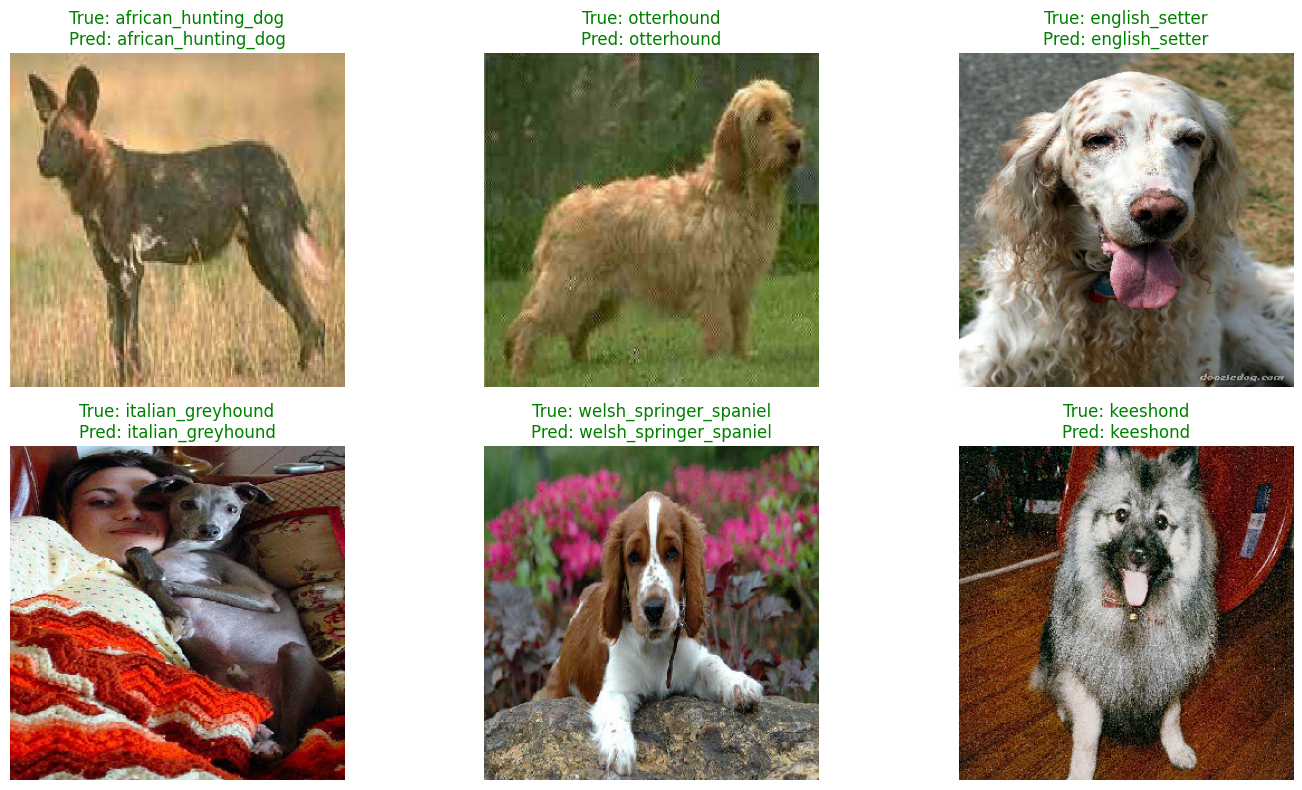

In [ ]:
import matplotlib.pyplot as plt
import random
from tensorflow.keras.applications.efficientnet import preprocess_input

# Reverse class index mapping
class_indices = {v: k for k, v in train_gen.class_indices.items()}

sample_df = test_df.sample(6, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(15, 8))
for i, row in sample_df.iterrows():
    img_path = row['filepath']
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)

    preds = model.predict(img_preprocessed)
    top_idx = np.argmax(preds)
    pred_label = class_indices[top_idx]
    true_label = row['breed']

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_array.astype("uint8"))
    plt.axis('off')
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=('green' if pred_label == true_label else 'red'))

plt.tight_layout()
plt.show()


64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step
              precision    recall  f1-score      support
accuracy       0.910068  0.910068  0.910068     0.910068
macro avg      0.916132  0.908042  0.906831  1023.000000
weighted avg   0.916962  0.910068  0.908464  1023.000000


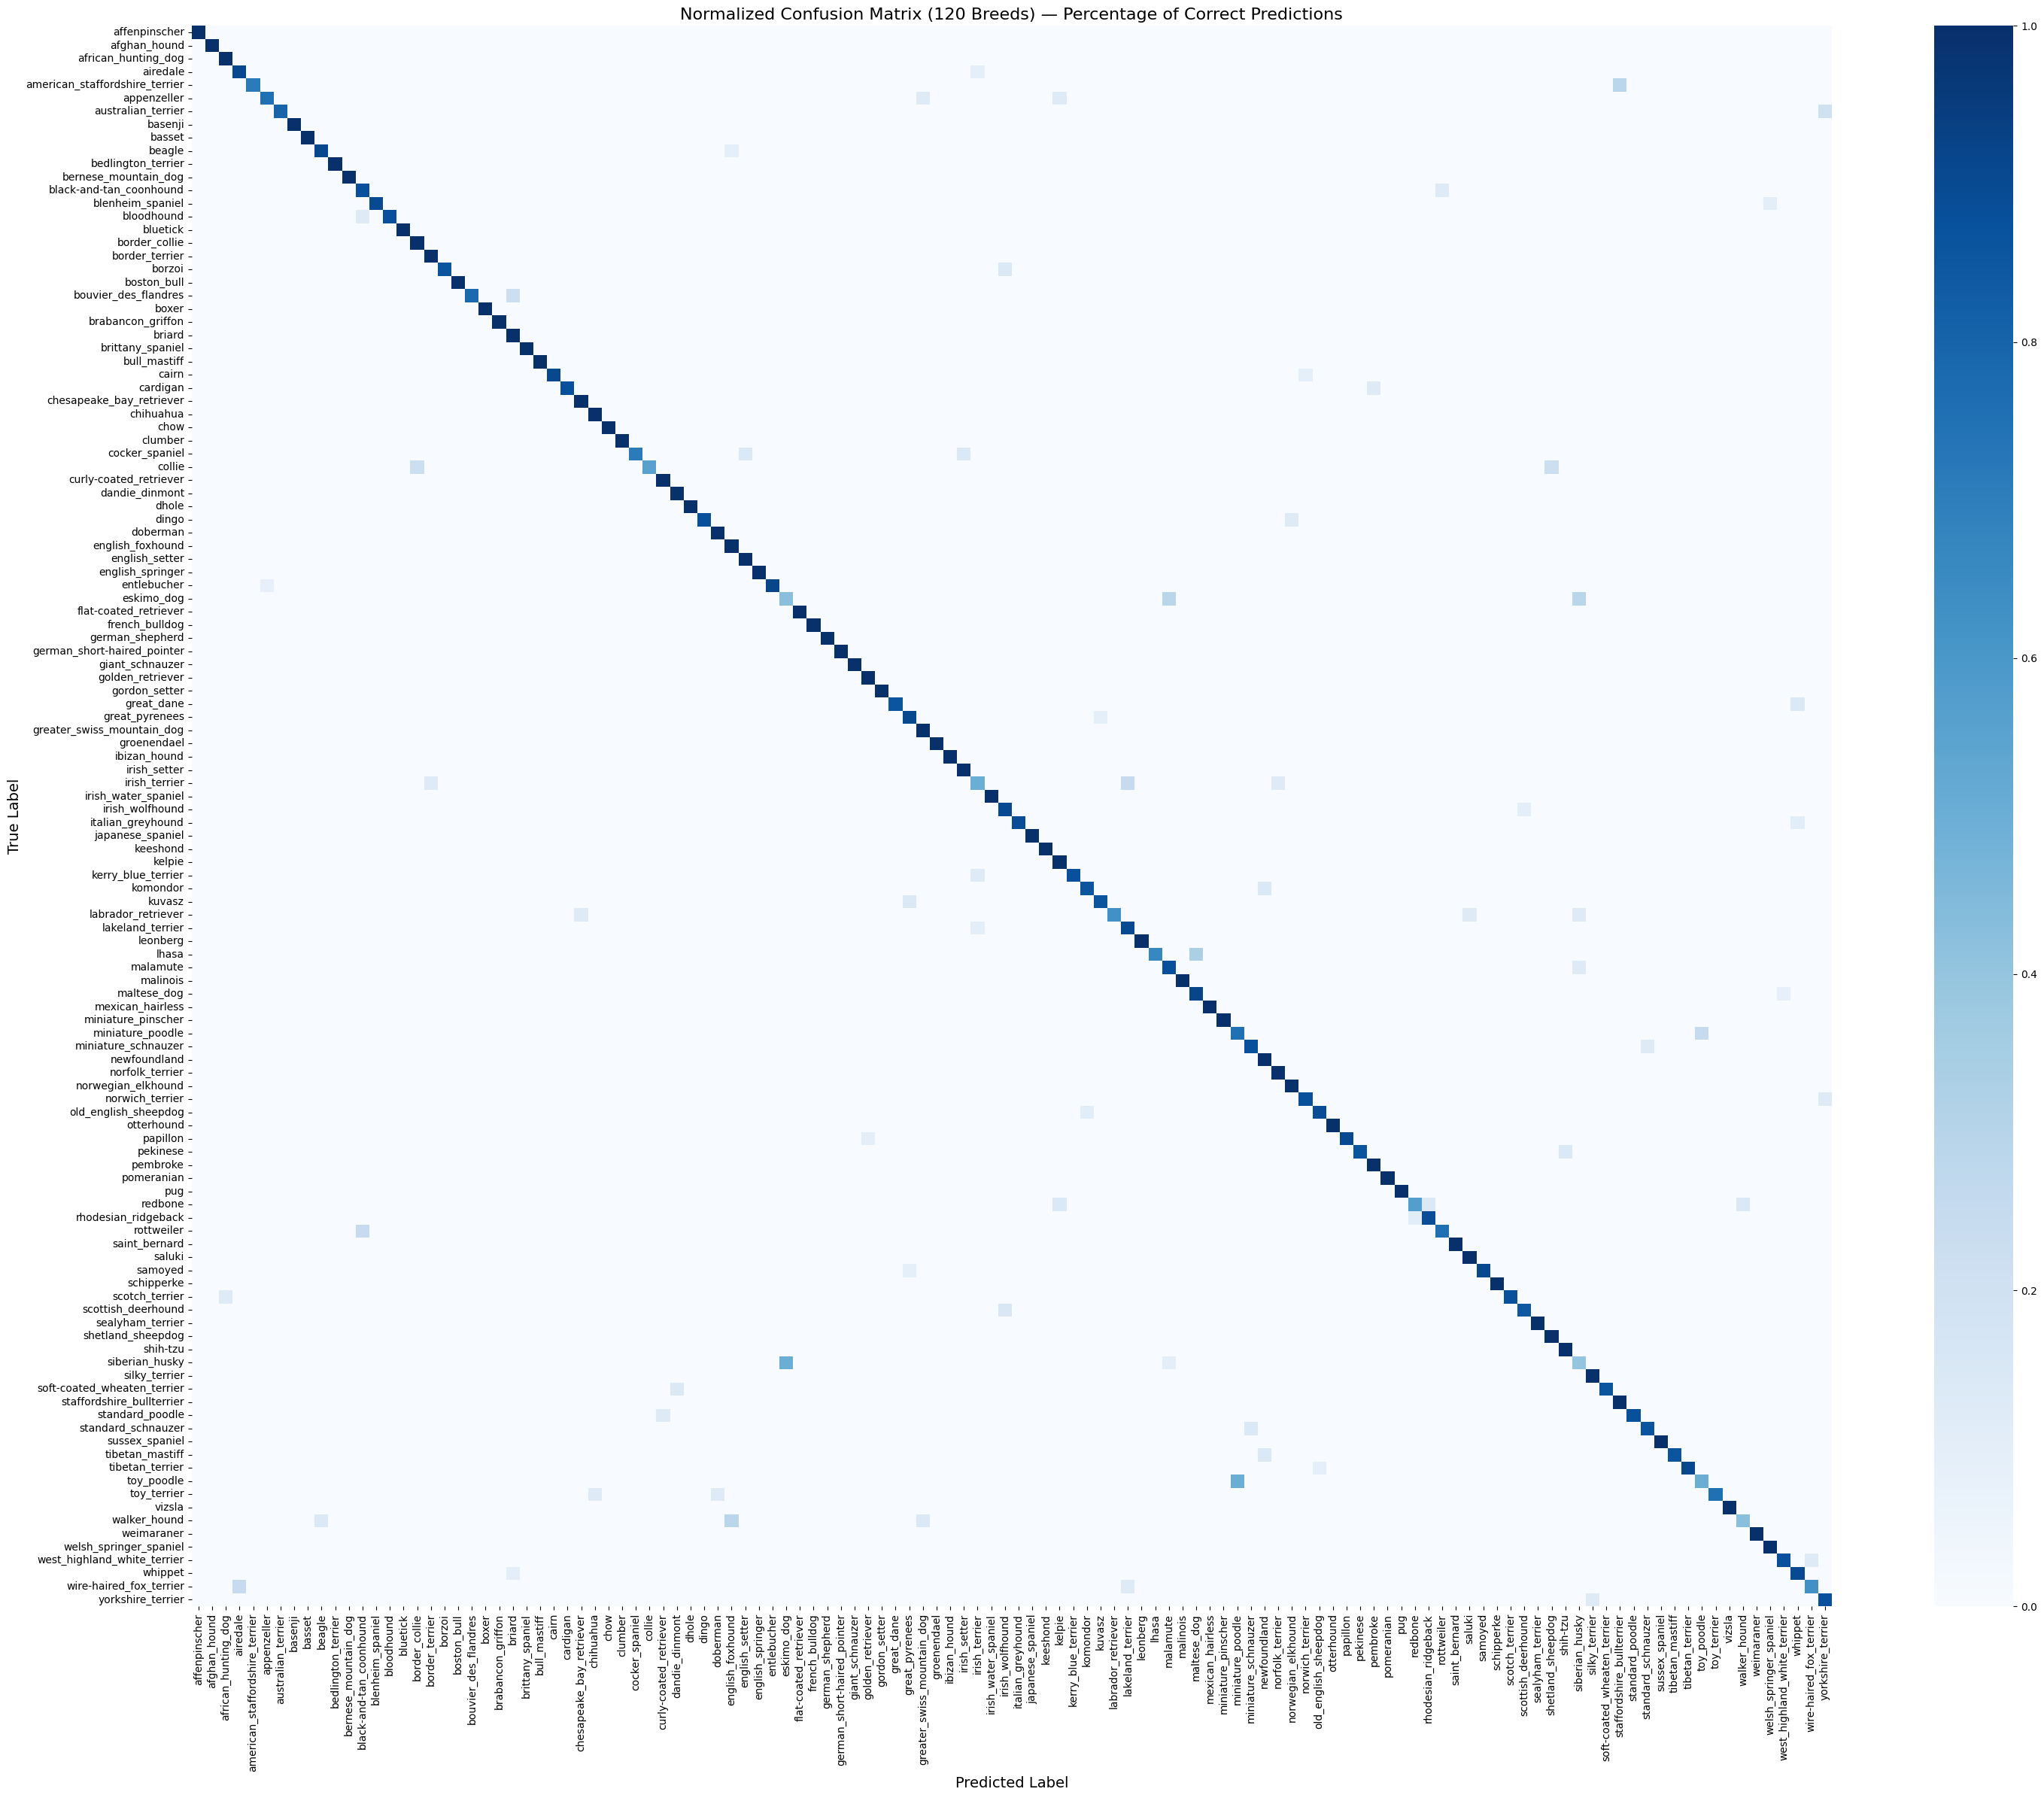

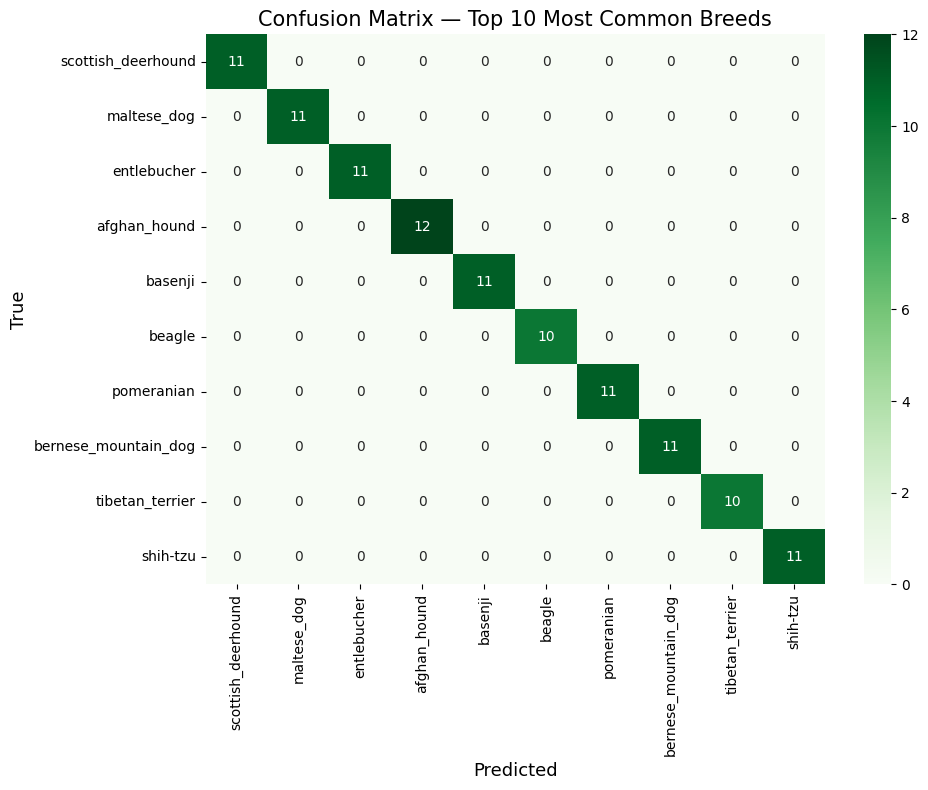


🐾 Top 10 Most Common Misclassifications:
True                            Pred                     
siberian_husky                  eskimo_dog                   5
toy_poodle                      miniature_poodle             4
lhasa                           maltese_dog                  3
bouvier_des_flandres            briard                       2
american_staffordshire_terrier  staffordshire_bullterrier    2
australian_terrier              yorkshire_terrier            2
miniature_poodle                toy_poodle                   2
scottish_deerhound              irish_wolfhound              2
wire-haired_fox_terrier         airedale                     2
walker_hound                    english_foxhound             2
dtype: int64


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Predict all test samples
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate classification report
target_names = list(train_gen.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df.tail(3))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalised matrix
plt.figure(figsize=(30, 24))
sns.heatmap(
    cm / np.sum(cm, axis=1, keepdims=True),
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Normalized Confusion Matrix (120 Breeds) — Percentage of Correct Predictions", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top 10 breeds confusion matrix
results_df = pd.DataFrame({
    'True': np.array(target_names)[y_true],
    'Pred': np.array(target_names)[y_pred]
})
top10 = results_df['True'].value_counts().index[:10]
subset_df = results_df[results_df['True'].isin(top10) & results_df['Pred'].isin(top10)]
cm_top10 = confusion_matrix(subset_df['True'], subset_df['Pred'], labels=top10)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_top10, annot=True, fmt='d', cmap='Greens',
            xticklabels=top10, yticklabels=top10)
plt.title("Confusion Matrix — Top 10 Most Common Breeds", fontsize=15)
plt.xlabel("Predicted", fontsize=13)
plt.ylabel("True", fontsize=13)
plt.tight_layout()
plt.show()

# Show top misclassifications
misclassified = results_df[results_df['True'] != results_df['Pred']]
print("\n🐾 Top 10 Most Common Misclassifications:")
print(misclassified.groupby(['True', 'Pred']).size().sort_values(ascending=False).head(10))


Saving 0a2a4ced84f11101720e47f4846945c6.jpg to 0a2a4ced84f11101720e47f4846945c6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


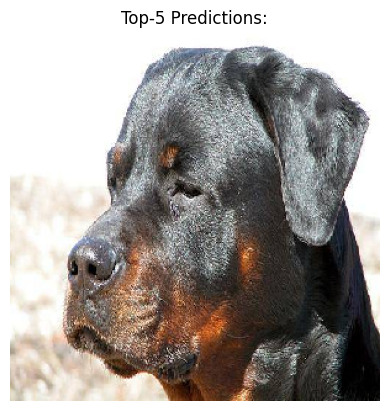

rottweiler: 0.9948
doberman: 0.0012
staffordshire_bullterrier: 0.0005
boxer: 0.0005
black-and-tan_coonhound: 0.0004


In [ ]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))

    preds = model.predict(img_preprocessed)
    top5_idx = np.argsort(preds[0])[-5:][::-1]
    top5_labels = [(list(train_gen.class_indices.keys())[i], preds[0][i]) for i in top5_idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title("Top-5 Predictions:")
    plt.show()

    for label, prob in top5_labels:
        print(f"{label}: {prob:.4f}")


# testing random picture


Upload an image to test (or type 'cancel' to stop):


Saving 0a1be1191b5c9d91392bb1e373600259.jpg to 0a1be1191b5c9d91392bb1e373600259.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


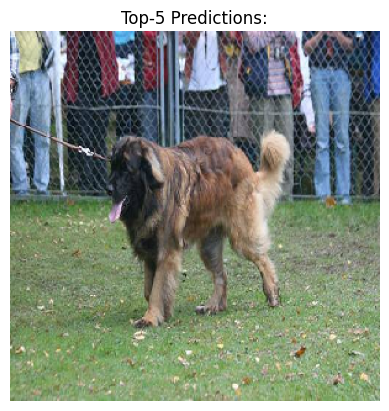

Prediction Results:
leonberg                  — 0.9880
tibetan_mastiff           — 0.0016
malinois                  — 0.0009
newfoundland              — 0.0007
saint_bernard             — 0.0005

Would you like to test another image? (y/n): y

Upload an image to test (or type 'cancel' to stop):


Saving 0a2a4ced84f11101720e47f4846945c6.jpg to 0a2a4ced84f11101720e47f4846945c6 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


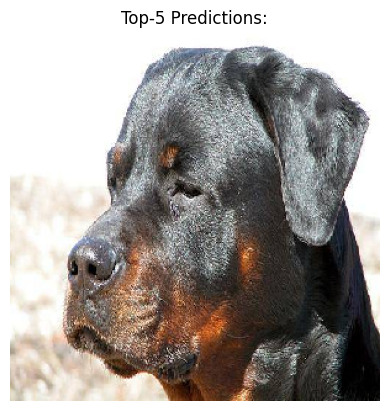

Prediction Results:
rottweiler                — 0.9948
doberman                  — 0.0012
staffordshire_bullterrier — 0.0005
boxer                     — 0.0005
black-and-tan_coonhound   — 0.0004

Would you like to test another image? (y/n): y

Upload an image to test (or type 'cancel' to stop):


Saving 0a4ef19459cd2100977b052de5f46231.jpg to 0a4ef19459cd2100977b052de5f46231.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


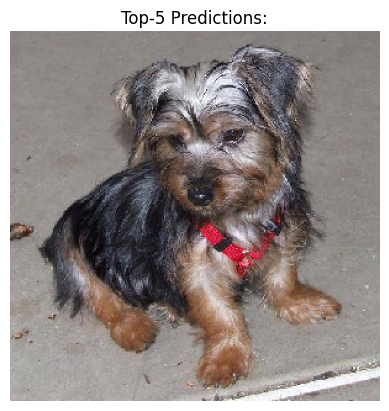

Prediction Results:
silky_terrier             — 0.4764
yorkshire_terrier         — 0.4219
australian_terrier        — 0.0672
norfolk_terrier           — 0.0220
toy_terrier               — 0.0017

Would you like to test another image? (y/n): y

Upload an image to test (or type 'cancel' to stop):


Saving 0a342feb5c2100a12bcd15326cf266c6.jpg to 0a342feb5c2100a12bcd15326cf266c6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


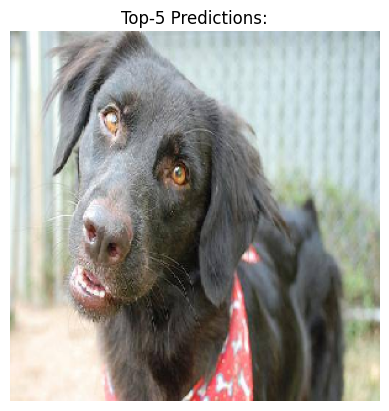

Prediction Results:
flat-coated_retriever     — 0.9619
labrador_retriever        — 0.0253
newfoundland              — 0.0021
golden_retriever          — 0.0021
black-and-tan_coonhound   — 0.0011

Would you like to test another image? (y/n): y

Upload an image to test (or type 'cancel' to stop):


Saving 00102ee9d8eb90812350685311fe5890.jpg to 00102ee9d8eb90812350685311fe5890.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


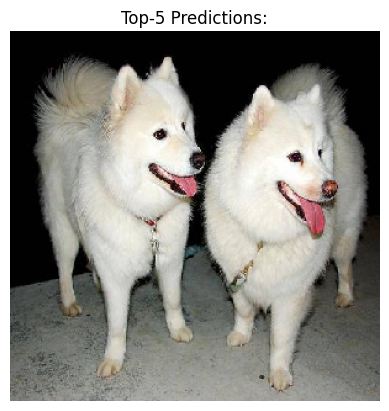

Prediction Results:
samoyed                   — 0.9854
keeshond                  — 0.0046
pomeranian                — 0.0046
eskimo_dog                — 0.0020
siberian_husky            — 0.0008

Would you like to test another image? (y/n): y

Upload an image to test (or type 'cancel' to stop):


Saving 001510bc8570bbeee98c8d80c8a95ec1.jpg to 001510bc8570bbeee98c8d80c8a95ec1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


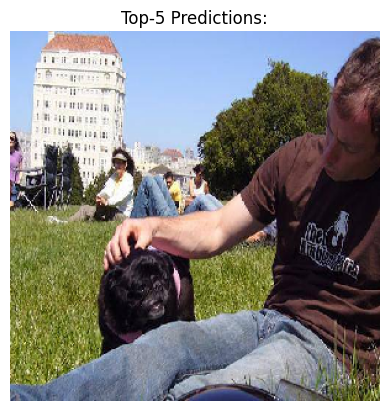

Prediction Results:
pug                       — 0.8303
pekinese                  — 0.0672
newfoundland              — 0.0631
tibetan_mastiff           — 0.0105
affenpinscher             — 0.0062

Would you like to test another image? (y/n): y

Upload an image to test (or type 'cancel' to stop):


Saving 031224_GoodLookEvents_041_v2-scaled.jpg to 031224_GoodLookEvents_041_v2-scaled.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


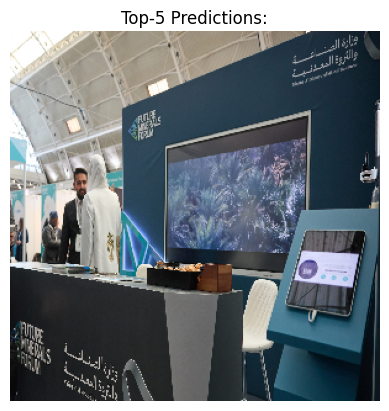

Prediction Results:
rhodesian_ridgeback       — 0.0548
chesapeake_bay_retriever  — 0.0396
great_dane                — 0.0388
mexican_hairless          — 0.0289
irish_wolfhound           — 0.0284

Would you like to test another image? (y/n): y

Upload an image to test (or type 'cancel' to stop):


Saving 1751983078516.jpeg to 1751983078516.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


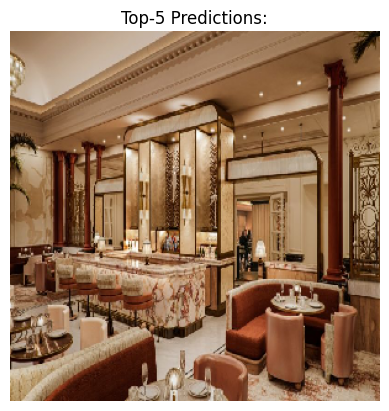

Prediction Results:
shih-tzu                  — 0.0268
boxer                     — 0.0264
malinois                  — 0.0256
great_dane                — 0.0248
lhasa                     — 0.0203

Would you like to test another image? (y/n): n
Exiting image testing loop.


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

while True:
    print("\nUpload an image to test (or type 'cancel' to stop):")
    uploaded = files.upload()

    # If you cancels or uploads nothing
    if not uploaded:
        print("No file uploaded. Stopping loop.")
        break

    for filename in uploaded.keys():
        img_path = filename
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))

        preds = model.predict(img_preprocessed)
        top5_idx = np.argsort(preds[0])[-5:][::-1]
        top5_labels = [(list(train_gen.class_indices.keys())[i], preds[0][i]) for i in top5_idx]

        plt.imshow(img)
        plt.axis('off')
        plt.title("Top-5 Predictions:")
        plt.show()

        print("Prediction Results:")
        for label, prob in top5_labels:
            print(f"{label:<25} — {prob:.4f}")

    # Ask if you wants to continue
    cont = input("\nWould you like to test another image? (y/n): ").strip().lower()
    if cont not in ["y", "yes"]:
        print("Exiting image testing loop.")
        break
